# Data & Env Initialization

Download the meta file at https://www.kaggle.com/competitions/pku-autonomous-driving/data?select=train.csv for car locations and more. 

The format of the file can be found at https://www.kaggle.com/competitions/pku-autonomous-driving/data. 

In [1]:
import os, sys, random, gc

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import cv2
from tqdm import tqdm

import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader, SequentialSampler
from torchvision import transforms, utils

import math
import multiprocessing as mp

n_cpu = 0 # mp.cpu_count() # 

import warnings
warnings.filterwarnings("ignore")

n_cpu

0

# Constants

In [2]:
INF = 1e7

IMG_SHAPE = (2710, 3384) # size of ApolloCar3D images
h_out, w_out = 128, 256 # size of the window of 2D representations
camera_matrix = np.array([[2304.5479, 0,  1686.2379],
                          [0, 2305.8757, 1354.9849],
                          [0, 0, 1.]], dtype=np.float32)
camera_matrix_inv = np.linalg.inv(camera_matrix)

# Data Viz & Utils

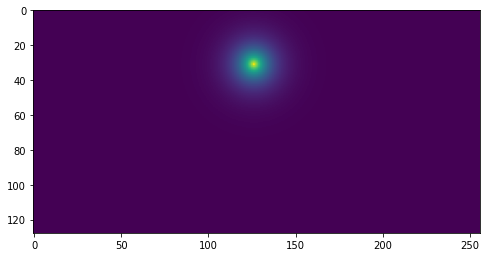

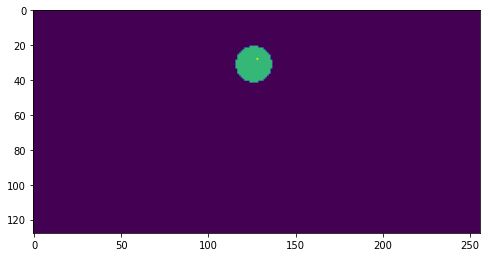

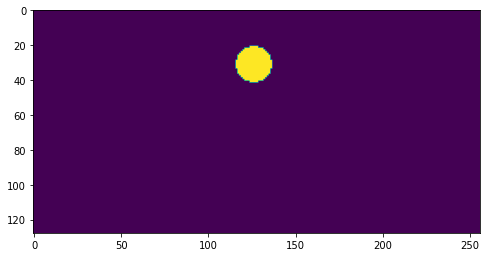

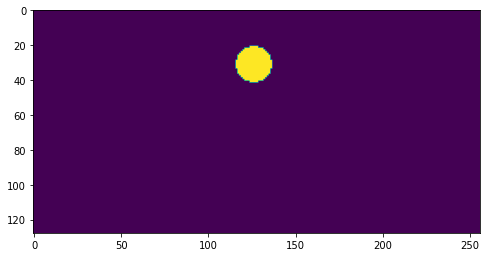

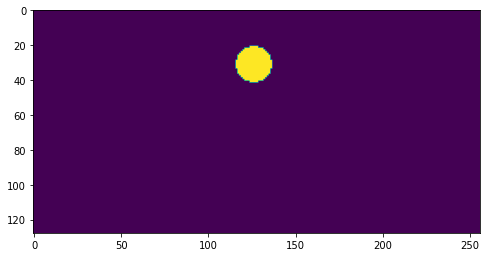

In [3]:
from math import sin, cos

def str2coords(s, names=['id', 'pitch', 'yaw', 'roll', 'x', 'y', 'z']):
    '''
    Input:
        s: PredictionString (e.g. from train dataframe)
        names: array of what to extract from the string
    Output:
        list of dicts with keys from `names`
    '''
    coords = []
    for l in np.array(s.split()).reshape([-1, 7]):
        coords.append(dict(zip(names, l.astype('float'))))
        if 'id' in coords[-1]:
            coords[-1]['id'] = int(coords[-1]['id'])
    return coords

def get_img_coords(s=None, trans_x=0., trans_y=0.):
    '''
    Input is a PredictionString (e.g. from train dataframe)
    Output is two arrays:
        xs: x coordinates in the image
        ys: y coordinates in the image
    '''
    world_mat = np.eye(4)
    
    trans = np.array([trans_x, trans_y, 0.0])
    
    world_mat[:3, 3]  = trans
    world_mat[:3, :3] = np.array([[1.0, 0.0, 0.0], 
                              [0.0, 1.0, 0.0], 
                              [0.0, 0.0, 1.0]]).T
    world_mat = world_mat[:3, :]
    
    x0, y0, z0, z1 = 0., 3., 7., 2e1
    xs = [x0]
    ys = [y0]
    zs = [z0]
    coords = [{"x":x0,"y":y0,"z":z0}]
    if np.random.choice([True, False], size=None):
        zs = [z1]
        coords = [{"x":x0,"y":y0,"z":z1}]
    
    if s is not None:
        coords = str2coords(s)
        xs = [c['x'] for c in coords]
        ys = [c['y'] for c in coords]
        zs = [c['z'] for c in coords]
    
    hs = [1.0 for c in coords]
    P = np.array(list(zip(xs, ys, zs, hs))).T

    img_p = np.dot(camera_matrix, np.dot(world_mat, P)).T
    img_p[:, 0] /= img_p[:, 2]
    img_p[:, 1] /= img_p[:, 2]
    img_cs = img_p[:, 0]
    img_rs = img_p[:, 1]
    
    img_zs = img_p[:, 2] # z = Distance from the camera
    
    return img_rs, img_cs, img_zs, coords

def _regr_preprocess(regr_dict, is_flip=False):
    regr_dict_co = dict()
    regr_dict_ag = dict()
    for name in ['x', 'y', 'z']:
        regr_dict_co[name] = regr_dict[name]
    
    return regr_dict_co
# https://www.kaggle.com/diegojohnson/centernet-objects-as-points
def get_heatmap(p_x, p_y, p_z, sigma=3.):
    X1 = np.linspace(1, w_out, w_out)
    Y1 = np.linspace(1, h_out, h_out)
    [X, Y] = np.meshgrid(X1, Y1)
    X = (X - p_x)*2.
    Y = (Y - p_y)*2.
    D2 = X * X + Y * Y
    E2 = sigma/(p_z*1e-2)
    heatmap = np.exp(-np.sqrt(D2) / E2)
    return heatmap

def get_mask_and_regr(labels=None, is_heatmap=True):
    regr_names = ['x', 'y', 'z', 'pitch', 'yaw', 'roll']
    one_mask = np.zeros([h_out, w_out, 1], dtype='float16')
    mask = np.zeros([h_out, w_out, 1], dtype='float16')
    bin_mask = np.zeros([h_out, w_out, 3], dtype='float16')
    regr_co_soft = np.zeros([h_out, w_out, 3], dtype='float16')
    regr_z = np.ones([h_out, w_out], dtype='float16') * INF
    if True:
        rs, cs, zs, coords = get_img_coords(s=labels)
    
        chosen_id = np.random.choice(range(len(rs)),size=None)
        for idx, (r, c, z, regr_dict) in enumerate(zip(rs, cs, zs, coords)):
            r = (r) * (h_out*2) / IMG_SHAPE[0] - h_out
            r = (r).astype('int')
            c = (c) * w_out / IMG_SHAPE[1]
            c = (c).astype('int')

            if (r >= 0) and (r < h_out) and (c >= 0) and (c < w_out):
                regr_dict_co = _regr_preprocess(regr_dict, is_flip=False)
                regr_co_soft[r, c] = [regr_dict_co[n] for n in sorted(regr_dict_co)]

                if is_heatmap:
                    heatmap = get_heatmap(c, r, z)
                    mask[:,:,0] = np.maximum(mask[:,:,0],heatmap[:,:])
                    rows, cols = np.where(heatmap > 0.25)

                    rd_p = np.random.choice(len(rows), size=None)
                    for i, (r0, c0) in enumerate(zip(rows, cols)):
                        if z < regr_z[r0, c0]:
                            regr_z[r0, c0] = z
                            regr_co_soft[r0, c0] = regr_co_soft[r, c]
                            
                            bin_mask[r0,c0,:] = 1.
                            
                            if idx==chosen_id:
                                bin_mask[r0,c0,:] = 2.
                                if i==rd_p:
                                    bin_mask[r0,c0,:] = 3.
                else:
                    bin_mask[r, c,:] = 1.
    
    return mask, bin_mask, regr_co_soft

class CarDataset(Dataset):
    """Car dataset."""

    def __init__(self, theta=[-0.,0.,0.]):
        self.theta = theta

    def __len__(self):
        return 640

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
            
        # PART 2
        mask_soft_, bin_mask_, regr_co_soft_ = get_mask_and_regr()
        mask_soft_ = np.rollaxis(mask_soft_, 2, 0)
        mask_soft = torch.from_numpy(mask_soft_).float()
        del mask_soft_
        
        rs, cs = np.where(bin_mask_[:,:,0]>1.)
        ys = (rs+h_out+.5) * IMG_SHAPE[0] / (h_out*2)
        xs = (cs+.5) * IMG_SHAPE[1] / w_out
        sky_labels = np.concatenate([np.reshape(xs,[-1,1])*regr_co_soft_[rs,cs,-1:],np.reshape(ys,[-1,1])*regr_co_soft_[rs,cs,-1:],regr_co_soft_[rs,cs,-1:]],axis=1)
        sky_label0 = np.dot(camera_matrix_inv, sky_labels.T).T
        sky_label0 = np.concatenate((np.zeros_like(sky_label0[:,:1]), np.zeros_like(sky_label0), sky_label0),axis=1)
        sky_label0 = np.reshape(sky_label0, [-1]).tolist()
        sky_label0 = ' '.join([str(elem) for elem in sky_label0])
        
        if len(sky_label0)==0:
            sky_label0 = None
        _, _, regr_co_soft_ = get_mask_and_regr(labels=sky_label0, is_heatmap=False)
        
        sky_labels = np.dot(camera_matrix_inv, sky_labels.T).T + np.reshape(np.array(self.theta), [-1,3])
        sky_labels = np.concatenate((np.zeros_like(sky_labels[:,:1]), np.zeros_like(sky_labels), sky_labels),axis=1)
        sky_labels = np.reshape(sky_labels, [-1]).tolist()
        sky_labels = ' '.join([str(elem) for elem in sky_labels])
        
        if len(sky_labels)==0:
            sky_labels = None
        _, sky_bin_mask_, sky_regr_co_soft_ = get_mask_and_regr(sky_labels, is_heatmap=False)

        bin_mask_ = np.rollaxis(bin_mask_, 2, 0)
        bin_mask = torch.from_numpy(bin_mask_).float()

        regr_co_soft_ = np.rollaxis(regr_co_soft_, 2, 0)
        regr_co_soft = torch.from_numpy(regr_co_soft_).float()
        
        sky_bin_mask_ = np.rollaxis(sky_bin_mask_, 2, 0)
        sky_bin_mask = torch.from_numpy(sky_bin_mask_).float()

        sky_regr_co_soft_ = np.rollaxis(sky_regr_co_soft_, 2, 0)
        sky_regr_co_soft = torch.from_numpy(sky_regr_co_soft_).float()
        
        del bin_mask_, regr_co_soft_, sky_bin_mask_, sky_regr_co_soft_
        
        mask_soft_, bin_mask_, regr_co_soft_, sky_bin_mask_, sky_regr_co_soft_ = None, None, None, None, None
        return [mask_soft, bin_mask, regr_co_soft, sky_bin_mask, sky_regr_co_soft]

dataset = CarDataset()

mask_soft, bin_mask, regr_co_soft, sky_bin_mask, sky_regr_co_soft = dataset[0]
mask_soft, bin_mask, regr_co_soft, sky_bin_mask, sky_regr_co_soft = mask_soft.float(), bin_mask.float(), regr_co_soft.float(), sky_bin_mask.float(), sky_regr_co_soft.float()

plt.figure(figsize=(8,8))
plt.imshow(mask_soft.permute(1,2,0).numpy().squeeze())
plt.show()

plt.figure(figsize=(8,8))
plt.imshow((bin_mask.permute(1,2,0).numpy()[:,:,-1]).squeeze())
plt.show()

plt.figure(figsize=(8,8))
plt.imshow(regr_co_soft.permute(1,2,0).numpy()[:,:,-1]/350.)
plt.show()

plt.figure(figsize=(8,8))
plt.imshow((sky_bin_mask.permute(1,2,0).numpy()[:,:,-1]).squeeze())
plt.show()

plt.figure(figsize=(8,8))
plt.imshow(sky_regr_co_soft.permute(1,2,0).numpy()[:,:,-1]/350.)
plt.show()

# Versions

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader

# configuration for reproducible
torch.manual_seed(0)
random.seed(0)
np.random.seed(0)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

print('numpy version: {}'.format(np.__version__))
print('pytorch version: {}'.format(torch.__version__))

numpy version: 1.19.5
pytorch version: 1.3.1+cu92


In [5]:
# Gets the GPU if there is one, otherwise the cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Sky Dataset

In [6]:
dataset = CarDataset()
train_loader = torch.utils.data.DataLoader(dataset, batch_size=1, num_workers=0)

In [7]:
mask_soft, bin_mask, regr_co_soft, sky_bin_mask, sky_regr_co_soft = None, None, None, None, None
for batch_idx, (mask_soft_batch, bin_mask_batch, regr_co_soft_batch, sky_bin_mask_batch, sky_regr_co_soft_batch) in enumerate(tqdm(train_loader)):
    rs, cs = np.where(bin_mask_batch[0,0,:,:] > 0.)
    indices = np.concatenate([np.reshape(rs,[-1,1]),np.reshape(cs,[-1,1])], axis=1)
    
    dat = (regr_co_soft_batch[0,:,:,:]).permute(1,2,0)[rs,cs,:]
    np.save("12Lamp/input_indices_{}.npy".format(batch_idx), indices)
    np.save("12Lamp/input_data_{}.npy".format(batch_idx), dat.numpy())
    
    
    rs, cs = np.where(sky_bin_mask_batch[0,0,:,:] > 0.)
    output = np.concatenate([np.reshape(rs,[-1,1]),np.reshape(cs,[-1,1])], axis=1)

    output_dat = (sky_regr_co_soft_batch[0,:,:,:]).permute(1,2,0)[rs,cs,:]
    np.save("12Lamp/output_indices_{}.npy".format(batch_idx), output)
    np.save("12Lamp/output_data_{}.npy".format(batch_idx), output_dat.numpy())

100%|████████████████████████████████████████████████████████████████████████████████| 640/640 [01:21<00:00,  7.86it/s]
